## Sección 1: Etiquetas con ventana (t+1h, t+3h]

In [ ]:
# ============================================================
# 10 - Dataset de entrenamiento
# Sección 1 — Etiquetas con ventana (t+1h, t+3h]
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Rutas ---
RUTA_BASE  = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_CSV   = RUTA_BASE / "data" / "rainfall_subhourly"
RUTA_UMBRAL = RUTA_BASE / "data_ingestion" / "ground_truth" / "umbral_operativo_por_estacion.csv"
RUTA_SALIDA = RUTA_BASE / "data_ingestion" / "ground_truth" / "etiquetas_ground_truth_v2.parquet"

# --- Parámetros de la etiqueta ---
PASO_MIN       = 10   # minutos por paso (cadencia GOES)
INICIO_H       = 1    # hora de inicio de la ventana (exclusivo), (t+1h, y no t+0 porque se requiere al menos 1 hora de margen operativa real.
FIN_H          = 3    # hora de fin de la ventana (inclusivo), la ventana termina en t+3h]
BLOQUE_MIN     = 30   # minutos por bloque de cobertura mínimos para decidir que hay suficientes datos.
PASO_INICIO    = (INICIO_H * 60) // PASO_MIN    # = 6
PASO_FIN       = (FIN_H   * 60) // PASO_MIN     # = 18  (slice exclusivo)
PASOS_BLOQUE   = BLOQUE_MIN // PASO_MIN         # = 3
N_BLOQUES      = (PASO_FIN - PASO_INICIO) // PASOS_BLOQUE  # = 4
VENTANA_TOTAL  = PASO_FIN                       # = 18 pasos mínimos por timestamp

print(f"Ventana: (t+{INICIO_H}h, t+{FIN_H}h] → pasos {PASO_INICIO}..{PASO_FIN-1}")
print(f"Bloques de cobertura: {N_BLOQUES} × {BLOQUE_MIN} min = {PASOS_BLOQUE} pasos c/u")

Ventana: (t+1h, t+3h] → pasos 6..17
Bloques de cobertura: 4 × 30 min = 3 pasos c/u


**Linea de tiempo:**

```
t=0    t+10m  t+20m  ... t+1h         t+1.5h  t+2h  t+2.5h  t+3h
paso:  0      1      2   ... 6          9       12     15      17
              ← gap, no se usa →  |←── ventana de interés ────→|
                                  B1         B2    B3     B4
```

In [2]:
def etiquetar_estacion(csv_path: Path, umbral_mm_h: float) -> pd.DataFrame:
    """
    Calcula etiquetas con ventana (t+1h, t+3h] para una estación.

    Para cada timestamp t en grilla de 10 min:
        - etiqueta = 1  si ∃ τ ∈ (t+1h, t+3h] con intensidad_rolling(τ) ≥ umbral
        - etiqueta = 0  si ningún τ supera el umbral, con cobertura suficiente
        - etiqueta = NaN si algún bloque de 30 min dentro de la ventana está vacío

    Cobertura suficiente: ≥ 1 registro crudo en cada uno de los 4 bloques de 30 min.

    Returns
    -------
    DataFrame con columnas [timestamp, etiqueta]
    """
    # 1. Cargar datos sub-horarios
    df = pd.read_csv(
        csv_path,
        usecols=["fechaobservacion", "valorobservado"],
        parse_dates=["fechaobservacion"]
    )
    df = (df
          .dropna(subset=["valorobservado"])
          .sort_values("fechaobservacion")
          .set_index("fechaobservacion"))

    if df.empty:
        return pd.DataFrame(columns=["timestamp", "etiqueta"])

    # 2. Intensidad horaria rolling 60 min (mm/h = suma de mm en la hora precedente)
    df["intensidad_mm_h"] = df["valorobservado"].rolling("60min").sum()

    # 3. Grilla de 10 min alineada con pandas resample (anchor midnight)
    t_min = df.index.min().floor(f"{PASO_MIN}min")
    t_max = df.index.max().ceil(f"{PASO_MIN}min")
    grilla = pd.date_range(t_min, t_max, freq=f"{PASO_MIN}min")

    # 4a. Cobertura: ¿hay ≥1 registro crudo en el bin de 10 min?
    conteo = df["valorobservado"].resample(f"{PASO_MIN}min").count().reindex(grilla, fill_value=0)
    tiene_dato = conteo.values > 0            # bool array (n,)

    # 4b. Evento: ¿la intensidad máxima en el bin supera el umbral?
    intens_max = (df["intensidad_mm_h"]
                  .resample(f"{PASO_MIN}min")
                  .max()
                  .reindex(grilla))           # float series, NaN donde no hay dato
    supera = (intens_max.fillna(0).values >= umbral_mm_h)  # NaN → 0 → False

    # 5. Vectorización: sliding window de tamaño VENTANA_TOTAL (18 pasos)
    n = len(grilla)
    n_validos = n - VENTANA_TOTAL + 1

    if n_validos <= 0:
        return pd.DataFrame(columns=["timestamp", "etiqueta"])

    hd_w = sliding_window_view(tiene_dato, VENTANA_TOTAL)   # (n_validos, 18)
    ev_w = sliding_window_view(supera,     VENTANA_TOTAL)   # (n_validos, 18)

    # Cobertura por bloque (cada bloque = PASOS_BLOQUE=3 columnas de 10 min)
    bloques_ok = np.ones(n_validos, dtype=bool)
    for b in range(N_BLOQUES):
        col_ini = PASO_INICIO + b * PASOS_BLOQUE
        col_fin = col_ini + PASOS_BLOQUE
        bloques_ok &= hd_w[:, col_ini:col_fin].any(axis=1)

    # Evento en ventana completa
    evento = ev_w[:, PASO_INICIO:PASO_FIN].any(axis=1)

    # Etiqueta final
    etiquetas = np.where(
        ~bloques_ok, np.nan,
        np.where(evento, 1.0, 0.0)
    )

    return pd.DataFrame({
        "timestamp": grilla[:n_validos],
        "etiqueta":  etiquetas
    })

In [3]:
# --- Procesar todas las estaciones ---
umbrales = pd.read_csv( RUTA_UMBRAL, dtype={"codigoestacion": str}).set_index("codigoestacion")

resultados = []
sin_umbral  = []

for csv_path in tqdm(sorted(RUTA_CSV.glob("*.csv")), desc="Estaciones"):
    cod = csv_path.stem
    if cod not in umbrales.index:
        sin_umbral.append(cod)
        continue
    umbral = float(umbrales.loc[cod, "umbral_mm_h"])
    df_est = etiquetar_estacion(csv_path, umbral)
    df_est.insert(0, "codigoestacion", cod)
    resultados.append(df_est)

if sin_umbral:
    print(f"\nArchivos sin umbral (ignorados): {sin_umbral}")

etiquetas_v2 = pd.concat(resultados, ignore_index=True)
etiquetas_v2.to_parquet(RUTA_SALIDA, index=False)
print(f"\nGuardado: {RUTA_SALIDA}")
print(f"Shape: {etiquetas_v2.shape}")

Estaciones: 100%|██████████| 70/70 [00:37<00:00,  1.88it/s]



Archivos sin umbral (ignorados): ['0021205700', '0021205791', '0021206780', '0021206980', '0021206990', '2120000104', '2120500204']

Guardado: C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\ground_truth\etiquetas_ground_truth_v2.parquet
Shape: (6200775, 3)


In [16]:
RUTA_GT = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\ground_truth")
DIA = "2024-03-20"

vieja = pd.read_parquet(RUTA_GT / "etiquetas_ground_truth.parquet")
nueva = pd.read_parquet(RUTA_GT / "etiquetas_ground_truth_v2.parquet")

# Filtrar al día de interés
vieja_dia = vieja[vieja["fechaobservacion"].dt.date.astype(str) == DIA].copy()
nueva_dia  = nueva[nueva["timestamp"].dt.date.astype(str) == DIA]

# Redondear la vieja a 10 min para alinearla con la nueva
vieja_dia["timestamp"] = vieja_dia["fechaobservacion"].dt.floor("10min")

# Estación con más positivos ese día (definición nueva)
estacion_top = (
    nueva_dia[nueva_dia["etiqueta"] == 1]
    .groupby("codigoestacion")
    .size()
    .idxmax()
)
print(f"Estación con más positivos el {DIA}: {estacion_top}\n")

# Comparación para esa estación
v = (vieja_dia[vieja_dia["codigoestacion"] == estacion_top]
     [["timestamp", "etiqueta"]]
     .rename(columns={"etiqueta": "etiq_vieja"}))

n = (nueva_dia[nueva_dia["codigoestacion"] == estacion_top]
     [["timestamp", "etiqueta"]]
     .rename(columns={"etiqueta": "etiq_nueva"}))

comp = n.merge(v, on="timestamp", how="left").sort_values("timestamp")
print(comp.to_string(index=False))

Estación con más positivos el 2024-03-20: 0021202220

          timestamp  etiq_nueva  etiq_vieja
2024-03-20 00:00:00         0.0           0
2024-03-20 00:00:00         0.0           0
2024-03-20 00:00:00         0.0           0
2024-03-20 00:00:00         0.0           0
2024-03-20 00:00:00         0.0           0
2024-03-20 00:00:00         0.0           0
2024-03-20 00:00:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:10:00         0.0           0
2024-03-20 00:20:00         0.0           0
2024-03-20 00:20:00         0.0           0
2024-03-20 00:20:00         0.0           0
2024-03-20 00:20:00         0.0           0
2024-03-20 00:20:00   

timestamp|etiq_nueva|etiq_vieja|lectura
-|-|-|-
11:30|0|1|vieja ve lluvia exacta en t+3h=14:30, nueva busca en (12:30, 14:30] y no la encuentra
11:40 → 12:20|1|1|ambas coinciden: anticipación al evento
12:30 → 14:30|1|0|← el caso de diseño exacto de la tesis: el evento ocurrió en la ventana pero no en el punto exacto t+3h → vieja lo pierde, nueva lo captura
14:40|0|0|lluvia disipada
14:50 → 15:40|1 / 0|1|posible segundo pulso corto a ~17:50
15:50 → 17:40|1|0|nuevamente nueva captura, vieja no ve nada
17:50 →|0|0|evento terminado

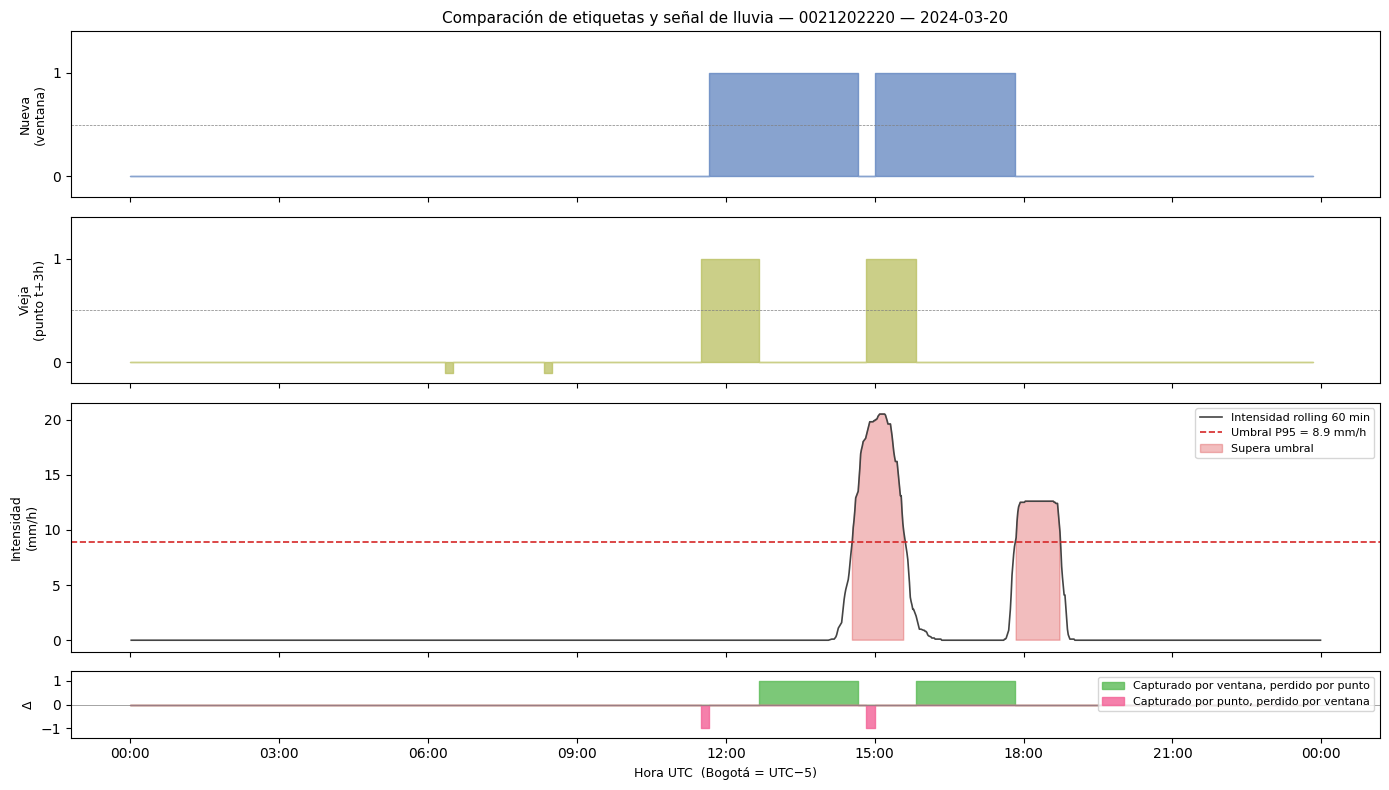

In [ ]:
# --- Cargar señal de lluvia de la estación ---
csv_est = RUTA_CSV / f"{estacion_top}.csv"
umbral_est = float(umbrales.loc[estacion_top, "umbral_mm_h"])

df_raw = (
    pd.read_csv(csv_est, usecols=["fechaobservacion", "valorobservado"],
                parse_dates=["fechaobservacion"])
    .dropna(subset=["valorobservado"])
    .sort_values("fechaobservacion")
    .set_index("fechaobservacion")
)
df_raw["intensidad_mm_h"] = df_raw["valorobservado"].rolling("60min").sum()

# Filtrar al día de interés
dia_dt = pd.Timestamp(DIA)
df_dia = df_raw.loc[dia_dt : dia_dt + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)]

# --- Figura con 4 paneles ---
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1.5, 0.4]})

ts = comp_plot["timestamp"]

# Panel 1 — Definición nueva
ax1 = axes[0]
ax1.fill_between(ts, comp_plot["etiq_nueva"].fillna(-0.1),
                 step="post", alpha=0.7, color="#567cbb")
ax1.set_ylim(-0.2, 1.4)
ax1.set_yticks([0, 1])
ax1.set_ylabel("Nueva\n(ventana)", fontsize=9)
ax1.set_title(f"Comparación de etiquetas y señal de lluvia — {estacion_top} — {DIA}", fontsize=11)
ax1.axhline(0.5, color="gray", lw=0.5, ls="--")

# Panel 2 — Definición vieja
ax2 = axes[1]
ax2.fill_between(ts, comp_plot["etiq_vieja"].fillna(-0.1),
                 step="post", alpha=0.7, color="#b5bb56")
ax2.set_ylim(-0.2, 1.4)
ax2.set_yticks([0, 1])
ax2.set_ylabel("Vieja\n(punto t+3h)", fontsize=9)
ax2.axhline(0.5, color="gray", lw=0.5, ls="--")

# Panel 3 — Intensidad rolling 60 min + umbral
ax3 = axes[2]
ax3.plot(df_dia.index, df_dia["intensidad_mm_h"],
         color="#444", lw=1.2, label="Intensidad rolling 60 min")
ax3.axhline(umbral_est, color="#d62728", lw=1.2, ls="--",
            label=f"Umbral P95 = {umbral_est:.1f} mm/h")
ax3.fill_between(df_dia.index, df_dia["intensidad_mm_h"],
                 where=(df_dia["intensidad_mm_h"] >= umbral_est),
                 alpha=0.3, color="#d62728", label="Supera umbral")
ax3.set_ylabel("Intensidad\n(mm/h)", fontsize=9)
ax3.legend(fontsize=8, loc="upper right")

# Panel 4 — Diferencia
ax4 = axes[3]
ganancia = ((comp_plot["etiq_nueva"] == 1) & (comp_plot["etiq_vieja"] == 0)).astype(float)
perdida  = ((comp_plot["etiq_nueva"] == 0) & (comp_plot["etiq_vieja"] == 1)).astype(float)
ax4.fill_between(ts,  ganancia, step="post", color="#5bbb56", alpha=0.8)
ax4.fill_between(ts, -perdida,  step="post", color="#f36196", alpha=0.8)
ax4.set_ylim(-1.4, 1.4)
ax4.set_yticks([-1, 0, 1])
ax4.set_ylabel("Δ", fontsize=9)
ax4.axhline(0, color="gray", lw=0.5)

patch_g = mpatches.Patch(color="#5bbb56", alpha=0.8, label="Capturado por ventana, perdido por punto")
patch_r = mpatches.Patch(color="#f36196", alpha=0.8, label="Capturado por punto, perdido por ventana")
ax4.legend(handles=[patch_g, patch_r], fontsize=8, loc="upper right")

ax4.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
ax4.set_xlabel("Hora UTC  (Bogotá = UTC−5)", fontsize=9)

plt.tight_layout()
plt.show()

### Acerca de definición de etiqueta y construcción de `etiquetas_ground_truth_v2.parquet`

La variable objetivo es binaria:
- etiqueta = 1 si ocurre lluvia fuerte en la ventana (t+1h, t+3h] para la estación e;
- etiqueta = 0 si no ocurre;
- NaN si el intervalo no tiene cobertura suficiente (al menos un registro por cada bloque de 30 min dentro de la ventana).

**Por qué ventana y no punto.** Una alternativa natural es evaluar la etiqueta en un único instante futuro — por ejemplo, t+3h exacto. El problema es estructural: si una tormenta inicia en t, alcanza su pico en t+1.5h y se disipa antes de t+3h, la etiqueta puntual la registra como negativa aunque el evento haya ocurrido íntegramente dentro de la ventana de anticipación y una alerta habría sido operativamente útil. La figura anterior ilustra este efecto para la estación 0021202220 el 20 de marzo de 2024: la definición puntual 
produce bloques positivos desplazados respecto a los picos reales de intensidad, mientras que la definición de ventana los cubre correctamente. El panel Δ muestra que la ganancia es asimétrica y favorable: la ventana recupera positivos que el punto perdía en los tramos de anticipación genuina, sin introducir un número comparable de falsos positivos.

**Por qué (t+1h, t+3h] y no (t, t+3h].** El límite inferior en t+1h cumple dos funciones. La primera es operativa: excluye los eventos ya en curso entre t y t+1h, para los cuales el margen de respuesta sería insuficiente. La segunda es de aprendizaje: orienta al modelo hacia las señales precursoras tempranas — el enfriamiento incipiente del tope de nube y el incremento de vapor de agua troposférico — y no hacia la convección ya iniciada, en la que las señales satelitales son trivialmente detectables.

**Resultado.** La fracción de positivos pasa de 0.27 % (definición puntual) a 0.70 %, con 28,388 positivos sobre 4,083,005 pares válidos (estación, timestamp). El ciclo diurno de pos_pct, con pico entre las 12–15h UTC (7–10h Bogotá), es consistente con el forzamiento diurno de la convección sobre la Sabana documentado por Casallas-García et al. (2023), lo que confirma que la señal capturada es física y no un artefacto del pipeline.

El parquet `etiquetas_ground_truth.parquet`, basado en la definición puntual, no se utiliza en ninguna etapa posterior de este trabajo.

In [4]:
# --- Reporte ---
validas = etiquetas_v2.dropna(subset=["etiqueta"])
n_total     = len(etiquetas_v2)
n_validos   = len(validas)
n_nan       = n_total - n_validos
n_pos       = (validas["etiqueta"] == 1).sum()
n_neg       = (validas["etiqueta"] == 0).sum()
frac_pos    = n_pos / n_validos

print("=" * 55)
print(f"Pares (estación, timestamp) totales   : {n_total:>12,}")
print(f"  Con etiqueta válida                 : {n_validos:>12,}")
print(f"  NaN (cobertura insuficiente)        : {n_nan:>12,}  ({n_nan/n_total:.1%})")
print(f"Positivos                             : {n_pos:>12,}")
print(f"Negativos                             : {n_neg:>12,}")
print(f"Fracción de positivos                 : {frac_pos:>11.4%}")
print(f"Ratio neg/pos                         : {n_neg/n_pos:>10.0f}:1")
print("=" * 55)

# Desglose por año (2024=train, 2025=test)
validas = validas.copy()
validas["anio"] = validas["timestamp"].dt.year
print("\nDesglose por año:")
print(
    validas.groupby("anio")["etiqueta"]
    .agg(
        total="count",
        positivos=lambda x: (x == 1).sum(),
        frac_pos=lambda x: f"{(x==1).mean():.4%}"
    )
    .to_string()
)

Pares (estación, timestamp) totales   :    6,200,775
  Con etiqueta válida                 :    4,083,005
  NaN (cobertura insuficiente)        :    2,117,770  (34.2%)
Positivos                             :       28,388
Negativos                             :    4,054,617
Fracción de positivos                 :     0.6953%
Ratio neg/pos                         :        143:1

Desglose por año:
        total  positivos frac_pos
anio                             
2024  1610756       9531  0.5917%
2025  2472249      18857  0.7627%


In [6]:
# NaN por estación (% sobre sus propios timestamps)
nan_por_estacion = (
    etiquetas_v2
    .assign(es_nan=etiquetas_v2["etiqueta"].isna())
    .groupby("codigoestacion")["es_nan"]
    .mean()
    .sort_values(ascending=False)
)
print(nan_por_estacion.head(15).to_string())
print(f"\nMediana de NaN% por estación: {nan_por_estacion.median():.1%}")

codigoestacion
0021201980    0.500277
2120000125    0.494891
2120000117    0.470605
0021202180    0.459458
2120000139    0.419077
2120000103    0.392114
0021202190    0.391024
2120000130    0.384157
0021202250    0.382136
2120000128    0.378406
0021202230    0.376932
2120700154    0.375900
0021206810    0.372553
2120000127    0.372145
2120000129    0.371514

Mediana de NaN% por estación: 34.0%


In [7]:
# NaN por hora UTC — ¿hay patrón horario?
etiquetas_v2["hora_utc"] = etiquetas_v2["timestamp"].dt.hour

resumen_hora = (
    etiquetas_v2
    .groupby("hora_utc")["etiqueta"]
    .agg(
        total="count",
        nan_pct=lambda x: x.isna().mean(),
        pos_pct=lambda x: (x == 1).sum() / x.notna().sum()
    )
)
print(resumen_hora.to_string())

           total   nan_pct   pos_pct
hora_utc                            
0         171283  0.336632  0.004630
1         171530  0.335680  0.004850
2         171228  0.336876  0.003656
3         170712  0.338894  0.002015
4         169778  0.342511  0.001243
5         168422  0.347758  0.000968
6         169070  0.345238  0.000887
7         169570  0.343302  0.000773
8         169540  0.343423  0.000725
9         170058  0.342084  0.001605
10        170380  0.340931  0.004038
11        169913  0.342740  0.009764
12        169808  0.343158  0.015041
13        170044  0.342261  0.018219
14        171198  0.337797  0.016244
15        171711  0.335813  0.014542
16        171215  0.337731  0.012762
17        169617  0.343912  0.011090
18        169894  0.342841  0.008758
19        170045  0.342257  0.007751
20        168835  0.346937  0.008239
21        168039  0.349367  0.007873
22        168745  0.346345  0.006015
23        172370  0.332303  0.005012


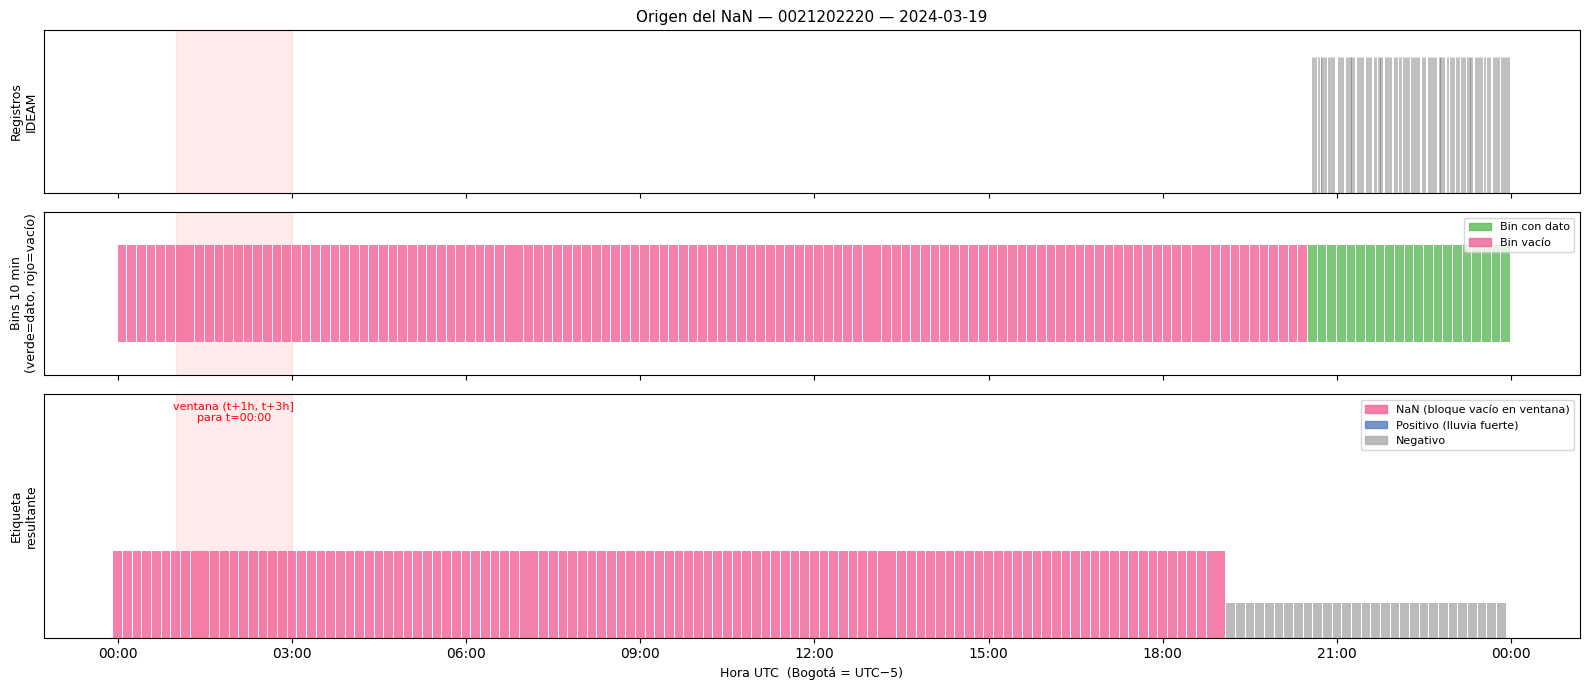

In [27]:
# Cargar dato crudo de la estación para el día con NaN parcial
DIA_NAN = "2024-03-19"
dia_dt = pd.Timestamp(DIA_NAN)

df_raw_nan = (
    pd.read_csv(csv_est,
                usecols=["fechaobservacion", "valorobservado"],
                parse_dates=["fechaobservacion"])
    .dropna(subset=["valorobservado"])
    .sort_values("fechaobservacion")
    .set_index("fechaobservacion")
)
df_dia_nan = df_raw_nan.loc[dia_dt : dia_dt + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)]

# Grilla de 10 min del día
grilla_dia = pd.date_range(dia_dt, periods=144, freq="10min")

# Para cada bin de 10 min: ¿tiene algún registro crudo?
conteo_bins = df_raw_nan["valorobservado"].resample("10min").count().reindex(grilla_dia, fill_value=0)
tiene_dato_dia = conteo_bins > 0  # bool

# Etiquetas del día para esta estación
etiq_dia = (
    etiq_est[etiq_est["fecha"] == DIA_NAN]
    .set_index("timestamp")["etiqueta"]
    .reindex(grilla_dia)
)

# ---- Figura ----
fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True,
                         gridspec_kw={"height_ratios": [0.8, 0.8, 1.2]})

# Panel 1 — Registros crudos IDEAM (ticks)
ax1 = axes[0]
if len(df_dia_nan) > 0:
    ax1.vlines(df_dia_nan.index, 0, 1, color="#444", lw=0.4, alpha=0.6)
ax1.set_ylim(0, 1.2)
ax1.set_yticks([])
ax1.set_ylabel("Registros\nIDEAM", fontsize=9)
ax1.set_title(f"Origen del NaN — {estacion_top} — {DIA_NAN}", fontsize=11)

# Panel 2 — Bins de 10 min: verde=con dato, rojo=vacío
ax2 = axes[1]
for i, (ts_bin, tiene) in enumerate(zip(grilla_dia, tiene_dato_dia)):
    color = "#5bbb56" if tiene else "#f36196"
    ax2.barh(0, width=pd.Timedelta(minutes=9), left=ts_bin,
             height=0.6, color=color, alpha=0.8)
ax2.set_ylim(-0.5, 0.5)
ax2.set_yticks([])
ax2.set_ylabel("Bins 10 min\n(verde=dato, rojo=vacío)", fontsize=9)

patch_v = mpatches.Patch(color="#5bbb56", alpha=0.8, label="Bin con dato")
patch_r = mpatches.Patch(color="#f36196", alpha=0.8, label="Bin vacío")
ax2.legend(handles=[patch_v, patch_r], fontsize=8, loc="upper right")

# Panel 3 — Etiqueta resultante por timestamp GOES
ax3 = axes[2]
for ts_bin in grilla_dia:
    etq = etiq_dia.get(ts_bin, np.nan)
    if pd.isna(etq):
        color, y = "#f36196", 0.5   # NaN
    elif etq == 1:
        color, y = "#567cbb", 1.0   # positivo
    else:
        color, y = "#aaaaaa", 0.2   # negativo

    ax3.bar(ts_bin, y, width=pd.Timedelta(minutes=9),
            color=color, alpha=0.8)

ax3.set_ylim(0, 1.4)
ax3.set_yticks([])
ax3.set_ylabel("Etiqueta\nresultante", fontsize=9)

patch_nan = mpatches.Patch(color="#f36196", alpha=0.8, label="NaN (bloque vacío en ventana)")
patch_pos = mpatches.Patch(color="#567cbb", alpha=0.8, label="Positivo (lluvia fuerte)")
patch_neg = mpatches.Patch(color="#aaaaaa", alpha=0.8, label="Negativo")
ax3.legend(handles=[patch_nan, patch_pos, patch_neg], fontsize=8, loc="upper right")

# Anotación explicativa: marcar una ventana concreta
# Buscar el primer timestamp NaN del día
primer_nan = etiq_dia[etiq_dia.isna()].index
if len(primer_nan) > 0:
    t_ej = primer_nan[0]
    t1 = t_ej + pd.Timedelta(hours=1)
    t3 = t_ej + pd.Timedelta(hours=3)
    for ax in axes:
        ax.axvspan(t1, t3, alpha=0.08, color="red", zorder=0)
    ax3.annotate(
        f"ventana (t+1h, t+3h]\npara t={t_ej.strftime('%H:%M')}",
        xy=(t1 + (t3 - t1) / 2, 1.25),
        ha="center", fontsize=8, color="red",
        arrowprops=None
    )

ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
ax3.set_xlabel("Hora UTC  (Bogotá = UTC−5)", fontsize=9)

plt.tight_layout()
plt.show()

- **Panel 1** — Registros IDEAM: la estación no transmitió prácticamente nada en todo el día. Los únicos ticks aparecen después de las 20:00 UTC.

- **Panel 2** — Bins de 10 min: rojo casi todo el día, verde solo en las últimas ~3 horas. La estación tuvo un corte de transmisión de unas 20 horas continuas.

- **Panel 3** — Etiqueta resultante: NaN desde medianoche hasta las ~19:00 UTC, y solo en las últimas horas aparecen negativos válidos (gris) — porque ahí sí hay datos en los 4 bloques de la ventana.

### Cobertura insuficiente y origen del NaN

El 34.2% de los pares (estación, timestamp) tiene etiqueta NaN — no por un problema del pipeline, sino por cortes reales de transmisión en la red de estaciones IDEAM. La figura del 19 de marzo de 2024 para la estación 0021202220 ilustra el caso típico: la estación no transmitió durante ~20 horas consecutivas, dejando la mayor parte del día sin ningún registro crudo. En ese contexto, relajar el criterio de cobertura de 4 bloques a 3 no recuperaría muestra útil — no falta un bloque de 30 min aislado, faltan horas enteras.

El análisis por hora UTC confirma que los NaN no tienen preferencia horaria: `nan_pct` oscila entre 33.2% y 35.0% a lo largo de las 24 horas (variación de 1.8 puntos porcentuales), lo que descarta un sesgo sistemático sobre las horas de mayor actividad convectiva. Los NaN son pérdida de muestra distribuida uniformemente, no un sesgo que afecte la representatividad del conjunto de datos.

Los 4,083,005 pares con etiqueta válida (65.8% del total) son los que alimentan todas las etapas siguientes. Los NaN se excluyen con `dropna()` al momento de construir los loaders de entrenamiento y nunca se imputan — la etiqueta de lluvia fuerte no es una variable que admita imputación.

**Esta limitación es consistente con lo anticipado en el diseño de la tesis**: _la disponibilidad histórica de los registros horarios de IDEAM constituye el 
techo efectivo del conjunto de datos, más que la propia cobertura satelital._

## Sección 2 — Cruce con inventario satelital

El índice del dataset se construye uniendo las etiquetas válidas con el inventario de imágenes GOES disponibles en disco. El join es por timestamp exacto — ambas fuentes comparten la misma grilla de 10 min porque las etiquetas se construyeron sobre esa grilla en la Sección 1.

De los 4,083,005 pares con etiqueta válida, 16,952 (0.4%) no tienen imagen GOES disponible — caen en los gaps documentados del inventario (42 gaps en G16, 8 en G19, máximo 9.2h y 3.5h respectivamente). La pérdida de positivos asociada es de 643 eventos (2.3% de los 28,388 originales), consistente con la distribución aleatoria de los gaps en el tiempo.

El índice resultante tiene 4,066,053 pares con imagen disponible. A cada par se le agregan las coordenadas de píxel (fila, col) de la estación en la grilla GOES, derivadas de estaciones_pixels.csv. La distancia máxima estación-píxel es 1.18 km, sub-píxel respecto a la resolución de 2.02 km/px del sensor ABI.

**Resultado final del índice:**

| | Total | Positivos | Fracción positivos |
|---|---|---|---|
| G16 (2024) | 1,595,767 | 8,897 | 0.56% |
| G19 (2025) | 2,470,286 | 18,848 | 0.76% |
| **Total** | **4,066,053** | **27,745** | **0.68%** |

El índice completo se guarda en `datasets/indice_completo.parquet` con columnas `codigoestacion`, `timestamp`, `etiqueta`, `satelite`, `filepath`, `fila`, `col`. Este archivo es el insumo de todas las etapas siguientes — ninguna etapa posterior lee las etiquetas o el inventario directamente.

In [31]:
# ============================================================
# Sección 2 — Cruce con inventario satelital
# ============================================================
RUTA_INVENTARIO = RUTA_BASE / "data_ingestion" / "satellite" / "inventario_goes.parquet"
RUTA_PIXELS     = RUTA_BASE / "data_ingestion" / "satellite" / "estaciones_pixels.csv"

# Cargar insumos
etiquetas = pd.read_parquet(RUTA_SALIDA)  # etiquetas_ground_truth_v2.parquet
inventario = pd.read_parquet(RUTA_INVENTARIO)
pixels = pd.read_csv(RUTA_PIXELS, dtype={"codigoestacion": str})
pixels["codigoestacion"] = pixels["codigoestacion"].str.zfill(10)


print("Etiquetas:  ", etiquetas.shape,  etiquetas.dtypes.to_dict())
print("Inventario: ", inventario.shape, inventario.dtypes.to_dict())
print("Píxeles:    ", pixels.shape,     pixels.columns.tolist())

Etiquetas:   (6200775, 3) {'codigoestacion': dtype('O'), 'timestamp': dtype('<M8[ns]'), 'etiqueta': dtype('float64')}
Inventario:  (104910, 3) {'timestamp': dtype('<M8[ns]'), 'satelite': dtype('O'), 'filepath': dtype('O')}
Píxeles:     (66, 9) ['codigoestacion', 'lat_est', 'lon_est', 'fila', 'col', 'lat_px', 'lon_px', 'dist_km', 'en_margen']


In [36]:
# 1. Descartar NaN — solo etiquetas válidas
etiq_validas = etiquetas.dropna(subset=["etiqueta"]).copy()
print(f"Etiquetas válidas: {len(etiq_validas):,}")

# 2. Join con inventario por timestamp exacto
indice = etiq_validas.merge(
    inventario[["timestamp", "satelite", "filepath"]],
    on="timestamp",
    how="inner"   # solo timestamps que tienen imagen GOES disponible
)
print(f"Tras cruce con inventario: {len(indice):,}")
print(f"Timestamps GOES sin cobertura perdidos: {len(etiq_validas) - len(indice):,}")

# 3. Agregar fila y columna del píxel de cada estación
indice = indice.merge(
    pixels[["codigoestacion", "fila", "col"]],
    on="codigoestacion",
    how="left"
)

# 4. Verificar que no quedaron estaciones sin píxel asignado
sin_pixel = indice["fila"].isna().sum()
if sin_pixel > 0:
    print(f"⚠️  {sin_pixel} filas sin píxel asignado — revisar estaciones_pixels.csv")
else:
    print("✓ Todas las estaciones tienen píxel asignado")

# 5. Reporte final
print("\n=== Índice del dataset ===")
print(f"Total pares (estación, timestamp GOES): {len(indice):,}")
print(f"Positivos: {(indice['etiqueta']==1).sum():,}  ({(indice['etiqueta']==1).mean():.4%})")
print(f"Negativos: {(indice['etiqueta']==0).sum():,}")
print(f"\nPor satélite:")
print(indice.groupby("satelite")["etiqueta"]
      .agg(total="count",
           positivos=lambda x: (x==1).sum(),
           frac_pos=lambda x: f"{(x==1).mean():.4%}")
      .to_string())

print(f"\nColumnas del índice: {indice.columns.tolist()}")

Etiquetas válidas: 4,083,005
Tras cruce con inventario: 4,066,053
Timestamps GOES sin cobertura perdidos: 16,952
✓ Todas las estaciones tienen píxel asignado

=== Índice del dataset ===
Total pares (estación, timestamp GOES): 4,066,053
Positivos: 27,745  (0.6824%)
Negativos: 4,038,308

Por satélite:
            total  positivos frac_pos
satelite                             
G16       1595767       8897  0.5575%
G19       2470286      18848  0.7630%

Columnas del índice: ['codigoestacion', 'timestamp', 'etiqueta', 'satelite', 'filepath', 'fila', 'col']


In [35]:
indice.head(5)

,codigoestacion,timestamp,etiqueta,satelite,filepath,fila,col
0,0021201980,2024-01-05 13:00:00,0.0,G16,C:\Users\diani\Documents\repositories\nowcasti...,99,101
1,0021201980,2024-01-05 13:10:00,0.0,G16,C:\Users\diani\Documents\repositories\nowcasti...,99,101
2,0021201980,2024-01-05 13:20:00,0.0,G16,C:\Users\diani\Documents\repositories\nowcasti...,99,101
3,0021201980,2024-01-05 13:30:00,0.0,G16,C:\Users\diani\Documents\repositories\nowcasti...,99,101
4,0021201980,2024-01-05 13:40:00,0.0,G16,C:\Users\diani\Documents\repositories\nowcasti...,99,101


`fila` y `col` son las coordenadas del píxel de la estación dentro de la grilla GOES recortada — el número de fila y de columna en la matriz de 198×199 píxeles que hay en el disco.

In [34]:
RUTA_INDICE_COMPLETO = RUTA_BASE / "datasets" / "indice_completo.parquet"
RUTA_INDICE_COMPLETO.parent.mkdir(exist_ok=True)
indice.to_parquet(RUTA_INDICE_COMPLETO, index=False)
print(f"Guardado: {RUTA_INDICE_COMPLETO}")
print(f"Shape: {indice.shape}")

Guardado: C:\Users\diani\Documents\repositories\nowcasting-bogota\datasets\indice_completo.parquet
Shape: (4066053, 7)


## Sección 3 — Split temporal

El dataset se divide en tres conjuntos con separación estrictamente temporal — sin mezcla de fechas entre splits — para garantizar que el modelo se evalúa sobre datos que no vio durante el entrenamiento.

- **Train:** enero–noviembre 2024. 1,383,931 pares, 8,245 positivos (0.60%).
- **Val:** diciembre 2024. 211,836 pares, 652 positivos (0.31%).
- **Test:** año completo 2025. 2,470,286 pares, 18,848 positivos (0.76%).

El corte de validación en diciembre 2024 preserva el máximo de positivos en entrenamiento (8,245 de los 8,897 disponibles en 2024) y deja un conjunto de validación con suficientes positivos para evaluar CSI con estabilidad. El conjunto de test no se balancea — mantiene las proporciones climatológicas reales (0.76% positivos), que es la condición bajo la cual el modelo operará en producción.

Una limitación de este corte es que diciembre 2024 es el mes de menor actividad convectiva del año en 2024 (0.31% de positivos, frente a 0.76% en test), lo que significa que el CSI de validación se estima sobre una climatología más seca que la del conjunto de prueba. El conjunto de validación sigue siendo útil para la selección de hiperparámetros, pero el CSI de test es la métrica de referencia para reportar el desempeño final del modelo.

Los tres índices se guardan en `datasets/indice_train.parquet`, `datasets/indice_val.parquet` y `datasets/indice_test.parquet`. Ninguna etapa posterior lee `indice_completo.parquet` directamente.

In [37]:
# ============================================================
# Sección 3 — Split temporal
# ============================================================

# Cargar índice completo
RUTA_INDICE_COMPLETO = RUTA_BASE / "datasets" / "indice_completo.parquet"
indice = pd.read_parquet(RUTA_INDICE_COMPLETO)

# Separación primaria: 2024=train+val, 2025=test
indice_2024 = indice[indice["timestamp"].dt.year == 2024].copy()
indice_test  = indice[indice["timestamp"].dt.year == 2025].copy()

# Distribución de positivos por mes en 2024 — decide el corte de validación
pos_por_mes = (
    indice_2024
    .assign(mes=indice_2024["timestamp"].dt.to_period("M"))
    .groupby("mes")["etiqueta"]
    .agg(total="count",
         positivos=lambda x: (x == 1).sum(),
         frac_pos=lambda x: f"{(x==1).mean():.4%}")
)
print("Distribución de positivos por mes en 2024:")
print(pos_por_mes.to_string())
print(f"\nTotal positivos en 2024: {(indice_2024['etiqueta']==1).sum():,}")

Distribución de positivos por mes en 2024:
          total  positivos frac_pos
mes                                
2024-01  131222         67  0.0511%
2024-02  141311       1113  0.7876%
2024-03  118262        580  0.4904%
2024-04  146882         97  0.0660%
2024-05   92919          0  0.0000%
2024-06    1996          0  0.0000%
2024-07  111972         25  0.0223%
2024-08   82299          0  0.0000%
2024-09  154454        470  0.3043%
2024-10  169260       1298  0.7669%
2024-11  233354       4595  1.9691%
2024-12  211836        652  0.3078%

Total positivos en 2024: 8,897


In [38]:
# Corte de validación: train=Ene–Oct 2024, val=Nov–Dic 2024
CORTE_VAL = pd.Timestamp("2024-12-01")

indice_train = indice_2024[indice_2024["timestamp"] < CORTE_VAL].copy()
indice_val   = indice_2024[indice_2024["timestamp"] >= CORTE_VAL].copy()

# Verificar que no hay filtración entre splits
assert indice_train["timestamp"].max() < indice_val["timestamp"].min(), \
    "⚠️ Hay solapamiento entre train y val"
assert indice_val["timestamp"].max() < indice_test["timestamp"].min(), \
    "⚠️ Hay solapamiento entre val y test"
print("✓ Separación temporal verificada — sin solapamiento entre splits")

# Reporte
def reporte_split(nombre, df):
    n      = len(df)
    n_pos  = (df["etiqueta"] == 1).sum()
    n_neg  = (df["etiqueta"] == 0).sum()
    t_ini  = df["timestamp"].min().date()
    t_fin  = df["timestamp"].max().date()
    print(f"\n{nombre}: {n:>10,} pares  |  {t_ini} → {t_fin}")
    print(f"  Positivos : {n_pos:>8,}  ({n_pos/n:.4%})")
    print(f"  Negativos : {n_neg:>8,}")
    print(f"  Ratio neg/pos: {n_neg/n_pos:.0f}:1" if n_pos > 0 else "  Sin positivos")

print("\n=== Distribución de splits ===")
reporte_split("Train ", indice_train)
reporte_split("Val   ", indice_val)
reporte_split("Test  ", indice_test)

# Confirmar que test NO está balanceado (proporciones climatológicas reales)
print(f"\n✓ Test mantiene proporciones climatológicas reales "
      f"({(indice_test['etiqueta']==1).mean():.4%} positivos)")

✓ Separación temporal verificada — sin solapamiento entre splits

=== Distribución de splits ===

Train :  1,383,931 pares  |  2024-01-01 → 2024-11-30
  Positivos :    8,245  (0.5958%)
  Negativos : 1,375,686
  Ratio neg/pos: 167:1

Val   :    211,836 pares  |  2024-12-01 → 2024-12-31
  Positivos :      652  (0.3078%)
  Negativos :  211,184
  Ratio neg/pos: 324:1

Test  :  2,470,286 pares  |  2025-01-01 → 2025-12-31
  Positivos :   18,848  (0.7630%)
  Negativos : 2,451,438
  Ratio neg/pos: 130:1

✓ Test mantiene proporciones climatológicas reales (0.7630% positivos)


In [39]:
RUTA_TRAIN = RUTA_BASE / "datasets" / "indice_train.parquet"
RUTA_VAL   = RUTA_BASE / "datasets" / "indice_val.parquet"
RUTA_TEST  = RUTA_BASE / "datasets" / "indice_test.parquet"

indice_train.to_parquet(RUTA_TRAIN, index=False)
indice_val.to_parquet(RUTA_VAL,   index=False)
indice_test.to_parquet(RUTA_TEST,  index=False)

print(f"✓ indice_train.parquet  — {len(indice_train):>10,} filas")
print(f"✓ indice_val.parquet    — {len(indice_val):>10,} filas")
print(f"✓ indice_test.parquet   — {len(indice_test):>10,} filas")

✓ indice_train.parquet  —  1,383,931 filas
✓ indice_val.parquet    —    211,836 filas
✓ indice_test.parquet   —  2,470,286 filas


## Sección 4 — Muestreo de negativos difíciles (near-miss)

Para mitigar el desbalance de clases (167:1 en train) y orientar el aprendizaje hacia los casos más informativos, los negativos de entrenamiento se dividen en dos pools:

- **Hard negatives (near-miss):** negativos de la misma estación dentro de ±24h de un evento positivo real. Son los casos más difíciles — condiciones atmosféricas similares al evento pero sin lluvia fuerte. 115,975 registros, ratio disponible 14:1 respecto a positivos.

- **Random negatives:** el resto de los negativos de entrenamiento, sin proximidad temporal a un evento positivo. 1,259,711 registros, ratio 153:1.

El ratio de muestreo entre positivos y negativos (hard y/o random) es un hiperparámetro que se decide en las notebooks de modelado (12–14), no aquí. El conjunto de validación y prueba no se balancea — mantiene las proporciones climatológicas reales.

In [42]:
# ============================================================
# Sección 4 — Pool de negativos difíciles (near-miss)
# Solo sobre el conjunto de entrenamiento
# ============================================================
VENTANA_NEAR_MISS = pd.Timedelta(hours=24)

pos_train = indice_train[indice_train["etiqueta"] == 1].copy()
neg_train = indice_train[indice_train["etiqueta"] == 0].copy()

print(f"Positivos en train : {len(pos_train):,}")
print(f"Negativos en train : {len(neg_train):,}")

# Indexar negativos por estación para búsqueda eficiente
neg_por_estacion = {
    cod: grp.set_index("timestamp").sort_index()
    for cod, grp in neg_train.groupby("codigoestacion")
}

# Para cada positivo, recoger todos los negativos de la misma estación en ±24h
hard_neg_ids = set()

for _, row in tqdm(pos_train.iterrows(), total=len(pos_train), desc="Near-miss"):
    cod = row["codigoestacion"]
    t   = row["timestamp"]
    if cod not in neg_por_estacion:
        continue
    neg_est = neg_por_estacion[cod]
    ventana = neg_est.loc[t - VENTANA_NEAR_MISS : t + VENTANA_NEAR_MISS]
    for ts in ventana.index:
        hard_neg_ids.add((cod, ts))

# Reconstruir DataFrame del pool
hard_neg_index = pd.DataFrame(list(hard_neg_ids),
                               columns=["codigoestacion", "timestamp"])
hard_neg_pool = neg_train.merge(hard_neg_index,
                                 on=["codigoestacion", "timestamp"],
                                 how="inner").copy()

# Negativos que NO son near-miss → pool de negativos aleatorios
random_neg_pool = neg_train.merge(hard_neg_index,
                                   on=["codigoestacion", "timestamp"],
                                   how="left", indicator=True)
random_neg_pool = random_neg_pool[random_neg_pool["_merge"] == "left_only"]\
                  .drop(columns="_merge").copy()

print(f"\n=== Pools de negativos ===")
print(f"Hard negatives (near-miss ±24h) : {len(hard_neg_pool):,}")
print(f"Random negatives (resto)        : {len(random_neg_pool):,}")
print(f"Total negativos train           : {len(neg_train):,}")
print(f"\nRatio hard_neg/pos disponible   : {len(hard_neg_pool)/len(pos_train):.0f}:1")
print(f"Ratio random_neg/pos disponible : {len(random_neg_pool)/len(pos_train):.0f}:1")
print(f"Ratio total_neg/pos disponible  : {len(neg_train)/len(pos_train):.0f}:1")

# Guardar los dos pools — el ratio de muestreo es hiperparámetro
# y se aplica en las notebooks de modelado (12-14)
RUTA_HARD  = RUTA_BASE / "datasets" / "pool_hard_neg_train.parquet"
RUTA_RAND  = RUTA_BASE / "datasets" / "pool_random_neg_train.parquet"

hard_neg_pool.to_parquet(RUTA_HARD,  index=False)
random_neg_pool.to_parquet(RUTA_RAND, index=False)

print(f"\n✓ pool_hard_neg_train.parquet   — {len(hard_neg_pool):,} filas")
print(f"✓ pool_random_neg_train.parquet — {len(random_neg_pool):,} filas")

Positivos en train : 8,245
Negativos en train : 1,375,686


Near-miss: 100%|██████████| 8245/8245 [00:04<00:00, 1739.89it/s]



=== Pools de negativos ===
Hard negatives (near-miss ±24h) : 115,975
Random negatives (resto)        : 1,259,711
Total negativos train           : 1,375,686

Ratio hard_neg/pos disponible   : 14:1
Ratio random_neg/pos disponible : 153:1
Ratio total_neg/pos disponible  : 167:1

✓ pool_hard_neg_train.parquet   — 115,975 filas
✓ pool_random_neg_train.parquet — 1,259,711 filas


## Sección 5 — Output final del índice

Los cinco archivos que constituyen el dataset de entrenamiento están verificados — sin NaN en columnas críticas y con las columnas mínimas requeridas por el loader de entrenamiento (`codigoestacion`, `timestamp`, `etiqueta`, `filepath`, `fila`, `col`).

| Split | Período | Total pares | Positivos | Fracción | Ratio |
|---|---|---|---|---|---|
| Train | 2024-01-01 → 2024-11-30 | 1,383,931 | 8,245 | 0.60% | 167:1 |
| Val | 2024-12-01 → 2024-12-31 | 211,836 | 652 | 0.31% | 324:1 |
| Test | 2025-01-01 → 2025-12-31 | 2,470,286 | 18,848 | 0.76% | 130:1 |
| **Total** | | **4,066,053** | **27,745** | **0.68%** | |

Los pools de negativos de entrenamiento están separados en dos archivos: `pool_hard_neg_train.parquet` (115,975 near-miss, ratio máximo 14:1) y `pool_random_neg_train.parquet` (1,259,711 aleatorios, ratio máximo 152:1). El ratio de muestreo entre positivos y negativos no se fija aquí — es un hiperparámetro que se decide empíricamente en las notebooks 12–14.

El conjunto de prueba no está balanceado y mantiene las proporciones climatológicas reales (0.76% de positivos), que son las condiciones bajo las cuales el modelo operará en producción. Ninguna etapa posterior modifica estos archivos.

In [45]:
# ============================================================
# Sección 5 — Output final del índice
# ============================================================

# Verificar que todos los archivos existen y cargarlos
archivos = {
    "indice_train"       : RUTA_BASE / "datasets" / "indice_train.parquet",
    "indice_val"         : RUTA_BASE / "datasets" / "indice_val.parquet",
    "indice_test"        : RUTA_BASE / "datasets" / "indice_test.parquet",
    "pool_hard_neg_train": RUTA_BASE / "datasets" / "pool_hard_neg_train.parquet",
    "pool_random_neg_train": RUTA_BASE / "datasets" / "pool_random_neg_train.parquet",
}

print("=== Verificación de archivos ===")
for nombre, ruta in archivos.items():
    existe = ruta.exists()
    tam_mb = ruta.stat().st_size / 1e6 if existe else 0
    print(f"{'✓' if existe else '✗'}  {nombre:<30} {tam_mb:.1f} MB")

# Cargar y verificar columnas
train = pd.read_parquet(archivos["indice_train"])
val   = pd.read_parquet(archivos["indice_val"])
test  = pd.read_parquet(archivos["indice_test"])

print(f"\nColumnas: {train.columns.tolist()}")

# Verificar columnas mínimas requeridas
cols_requeridas = {"codigoestacion", "timestamp", "etiqueta",
                   "filepath", "fila", "col"}
faltantes = cols_requeridas - set(train.columns)
if faltantes:
    print(f"⚠️  Columnas faltantes: {faltantes}")
else:
    print("✓ Todas las columnas requeridas presentes")

# Verificar ausencia de NaN en columnas críticas
for nombre, df in [("train", train), ("val", val), ("test", test)]:
    nans = df[list(cols_requeridas)].isna().sum()
    if nans.any():
        print(f"⚠️  NaN en {nombre}:\n{nans[nans > 0]}")
    else:
        print(f"✓ Sin NaN en columnas críticas ({nombre})")

# Reporte final consolidado
print("\n=== Resumen final del dataset ===")
print(f"{'Split':<10} {'Período':<25} {'Total':>10} {'Positivos':>10} "
      f"{'Fracción':>10} {'Ratio':>10}")
print("-" * 75)

for nombre, df in [("Train", train), ("Val", val), ("Test", test)]:
    t_ini = df["timestamp"].min().date()
    t_fin = df["timestamp"].max().date()
    n     = len(df)
    n_pos = (df["etiqueta"] == 1).sum()
    n_neg = (df["etiqueta"] == 0).sum()
    frac  = n_pos / n
    ratio = n_neg / n_pos
    print(f"{nombre:<10} {str(t_ini)+' → '+str(t_fin):<25} {n:>10,} "
          f"{n_pos:>10,} {frac:>9.4%} {ratio:>8.0f}:1")

print("-" * 75)
total     = len(train) + len(val) + len(test)
total_pos = ((train["etiqueta"]==1).sum() +
             (val["etiqueta"]==1).sum() +
             (test["etiqueta"]==1).sum())
print(f"{'Total':<10} {'':25} {total:>10,} {total_pos:>10,} "
      f"{total_pos/total:>9.4%}")

print(f"\n=== Pools de negativos (train) ===")
hard = pd.read_parquet(archivos["pool_hard_neg_train"])
rand = pd.read_parquet(archivos["pool_random_neg_train"])
pos  = (train["etiqueta"] == 1).sum()
print(f"Hard negatives (near-miss ±24h) : {len(hard):>10,}  "
      f"(ratio máximo disponible: {len(hard)//pos}:1)")
print(f"Random negatives                : {len(rand):>10,}  "
      f"(ratio máximo disponible: {len(rand)//pos}:1)")
print(f"\n✓ El test set mantiene proporciones climatológicas reales "
      f"— no balanceado.")
print(f"✓ El ratio de muestreo de negativos es un hiperparámetro "
      f"que se decide en las notebooks 12–14.")

=== Verificación de archivos ===
✓  indice_train                   14.0 MB
✓  indice_val                     0.8 MB
✓  indice_test                    25.1 MB
✓  pool_hard_neg_train            0.7 MB
✓  pool_random_neg_train          12.8 MB

Columnas: ['codigoestacion', 'timestamp', 'etiqueta', 'satelite', 'filepath', 'fila', 'col']
✓ Todas las columnas requeridas presentes
✓ Sin NaN en columnas críticas (train)
✓ Sin NaN en columnas críticas (val)
✓ Sin NaN en columnas críticas (test)

=== Resumen final del dataset ===
Split      Período                        Total  Positivos   Fracción      Ratio
---------------------------------------------------------------------------
Train      2024-01-01 → 2024-11-30    1,383,931      8,245   0.5958%      167:1
Val        2024-12-01 → 2024-12-31      211,836        652   0.3078%      324:1
Test       2025-01-01 → 2025-12-31    2,470,286     18,848   0.7630%      130:1
---------------------------------------------------------------------------
T

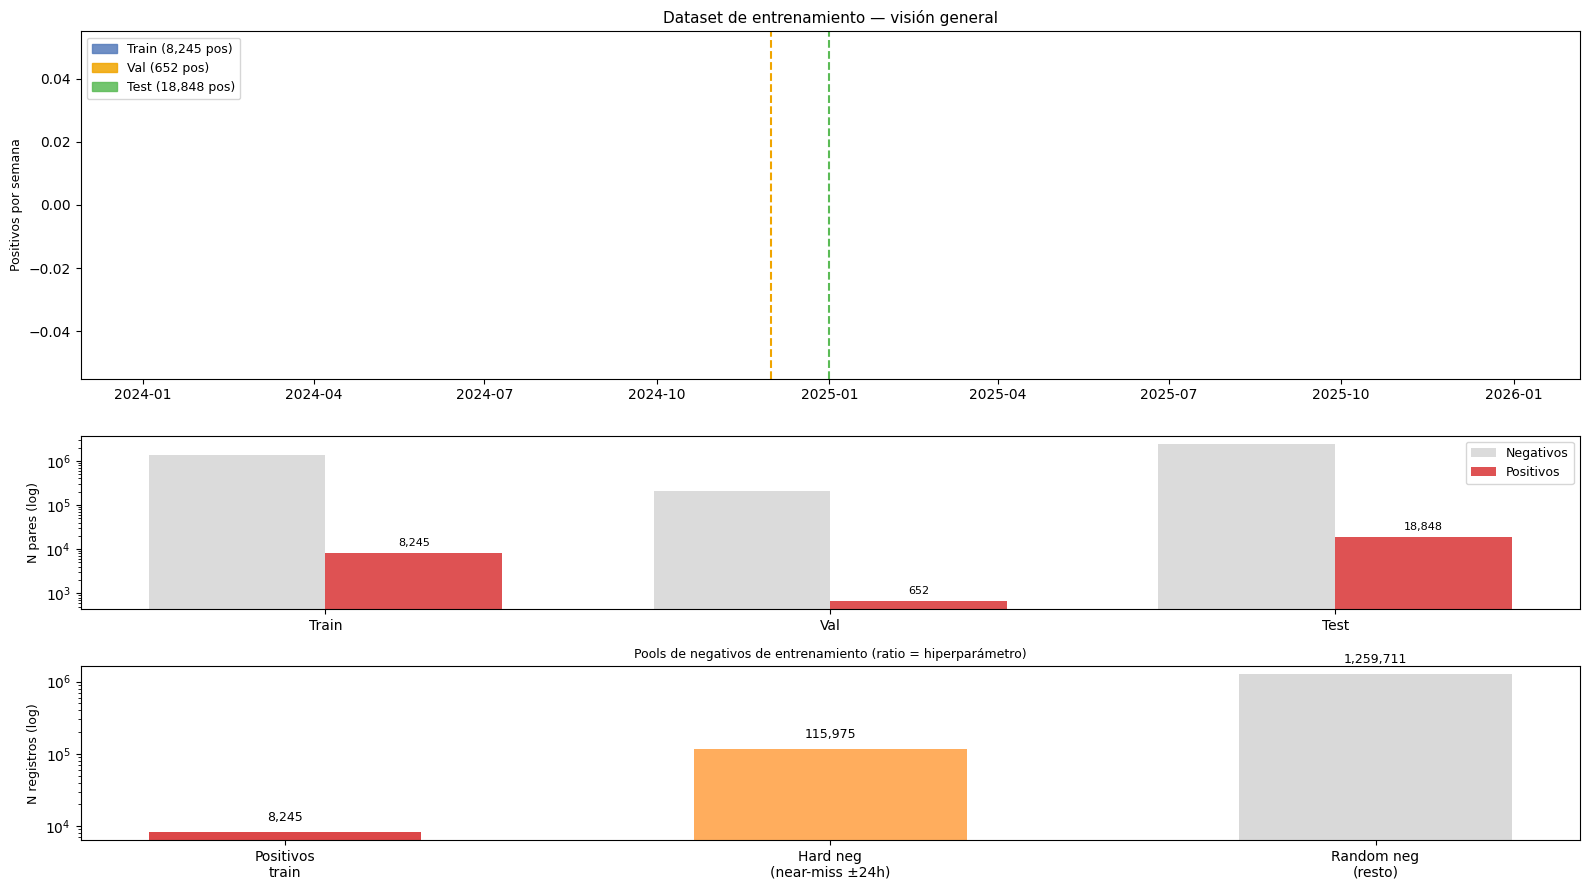

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), 
                          gridspec_kw={"height_ratios": [2, 1, 1]})

# --- Panel 1: Positivos por semana a lo largo del tiempo ---
ax1 = axes[0]

todos = pd.concat([train, val, test])
todos["semana"] = todos["timestamp"].dt.to_period("W").dt.start_time

pos_semana = (
    todos[todos["etiqueta"] == 1]
    .groupby("semana").size()
    .reindex(pd.date_range(todos["semana"].min(),
                           todos["semana"].max(), freq="W"), fill_value=0)
)

# Colorear por split
corte_val  = pd.Timestamp("2024-12-01")
corte_test = pd.Timestamp("2025-01-01")

for ts, val_s in pos_semana.items():
    if ts < corte_val:
        color = "#567cbb"
    elif ts < corte_test:
        color = "#f0a500"
    else:
        color = "#5bbb56"
    ax1.bar(ts, val_s, width=6, color=color, alpha=0.85)

# Líneas de corte
ax1.axvline(corte_val,  color="#f0a500", lw=1.5, ls="--", label="Corte val (dic 2024)")
ax1.axvline(corte_test, color="#5bbb56", lw=1.5, ls="--", label="Corte test (ene 2025)")

# Leyenda de splits
patch_tr = mpatches.Patch(color="#567cbb", alpha=0.85, label=f"Train (8,245 pos)")
patch_va = mpatches.Patch(color="#f0a500", alpha=0.85, label=f"Val (652 pos)")
patch_te = mpatches.Patch(color="#5bbb56", alpha=0.85, label=f"Test (18,848 pos)")
ax1.legend(handles=[patch_tr, patch_va, patch_te], fontsize=9, loc="upper left")
ax1.set_ylabel("Positivos por semana", fontsize=9)
ax1.set_title("Dataset de entrenamiento — visión general", fontsize=11)
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

# --- Panel 2: Distribución de clases por split ---
ax2 = axes[1]

splits   = ["Train", "Val", "Test"]
n_pos    = [8245, 652, 18848]
n_neg    = [1375686, 211184, 2451438]
colores  = ["#567cbb", "#f0a500", "#5bbb56"]

x = np.arange(len(splits))
w = 0.35

bars_neg = ax2.bar(x - w/2, n_neg, w, label="Negativos", color="lightgray", alpha=0.8)
bars_pos = ax2.bar(x + w/2, n_pos, w, label="Positivos", color="#d62728", alpha=0.8)

ax2.set_yscale("log")
ax2.set_xticks(x)
ax2.set_xticklabels(splits)
ax2.set_ylabel("N pares (log)", fontsize=9)
ax2.legend(fontsize=9)

for bar, n in zip(bars_pos, n_pos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
             f"{n:,}", ha="center", va="bottom", fontsize=8)

# --- Panel 3: Pools de negativos de train ---
ax3 = axes[2]

categorias = ["Positivos\ntrain", "Hard neg\n(near-miss ±24h)", "Random neg\n(resto)"]
valores    = [8245, 115975, 1259711]
colores3   = ["#d62728", "#ff9f40", "lightgray"]

bars3 = ax3.bar(categorias, valores, color=colores3, alpha=0.85, width=0.5)
ax3.set_yscale("log")
ax3.set_ylabel("N registros (log)", fontsize=9)
ax3.set_title("Pools de negativos de entrenamiento (ratio = hiperparámetro)", fontsize=9)

for bar, n in zip(bars3, valores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
             f"{n:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()